In [1]:
import sys

from pathlib import Path

import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from configuration import (
    LATENT_CHANNELS, BATCH_SIZE,
    VAE_CKPT_PATH, OUTPUT_DIR, KL_ANNEAL_EPOCHS, device,
)
from dataset.mel_dataset import MelDataset
from dataset.create_chunks import iter_chunks
from models import VAE

FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR  = OUTPUT_DIR / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

MUSDB_ROOT     = Path('../musdb18/musdb18_mixtures')
CHUNK_DURATION = 10
N_TRAIN_SONGS  = 15
AU_EPSILON     = 0.1

print('device:', device)

/home/matej/Documents/DIPLRAD/music_gen_v2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
vae = VAE().to(device)
ckpt = torch.load(VAE_CKPT_PATH, map_location=device)
vae.load_state_dict(ckpt['model_state'])
vae.eval()
history = ckpt.get('history', [])
print('Loaded VAE from', VAE_CKPT_PATH)

Loaded VAE from ../musdb18/output/vae_checkpoint.pt


In [3]:
train_files  = list(iter_chunks(MUSDB_ROOT, 'train', CHUNK_DURATION, N_TRAIN_SONGS))
print(f'Training chunks: {len(train_files)}')

train_ds     = MelDataset(train_files)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_mu     = []
all_logvar = []

with torch.no_grad():
    for x in tqdm(train_loader, desc='Encoding training set'):
        x   = x.to(device)
        mu, logvar = vae.encoder(x)        # (B, C, H, W)
        all_mu.append(mu.cpu())
        all_logvar.append(logvar.cpu())

mu_all     = torch.cat(all_mu,     dim=0)   # (N, C, H, W)
logvar_all = torch.cat(all_logvar, dim=0)
sigma_all  = torch.exp(0.5 * logvar_all)

print(f'mu shape: {mu_all.shape}')

Training chunks: 344


Encoding training set: 100%|██████████| 43/43 [00:08<00:00,  5.24it/s]

mu shape: torch.Size([344, 16, 10, 27])


In [4]:

mu_flat = mu_all.mean(dim=(2, 3))
channel_var = mu_flat.var(dim=0)

active_mask  = (channel_var > AU_EPSILON).numpy()
n_active     = int(active_mask.sum())

print(f'Active units (var > {AU_EPSILON}): {n_active} / {LATENT_CHANNELS}')
print('Per-channel variance:')
for c in range(LATENT_CHANNELS):
    flag = 'active' if active_mask[c] else 'not active'
    print(f'  ch {c:2d}: var={channel_var[c]:.4f}  {flag}')

Active units (var > 0.1): 10 / 16
Per-channel variance:
  ch  0: var=0.2645  active
  ch  1: var=0.1118  active
  ch  2: var=0.2387  active
  ch  3: var=0.0286  not active
  ch  4: var=0.5618  active
  ch  5: var=0.2887  active
  ch  6: var=0.1990  active
  ch  7: var=0.0557  not active
  ch  8: var=0.0327  not active
  ch  9: var=0.0203  not active
  ch 10: var=0.3957  active
  ch 11: var=0.3259  active
  ch 12: var=0.1650  active
  ch 13: var=0.0454  not active
  ch 14: var=0.0236  not active
  ch 15: var=0.1056  active


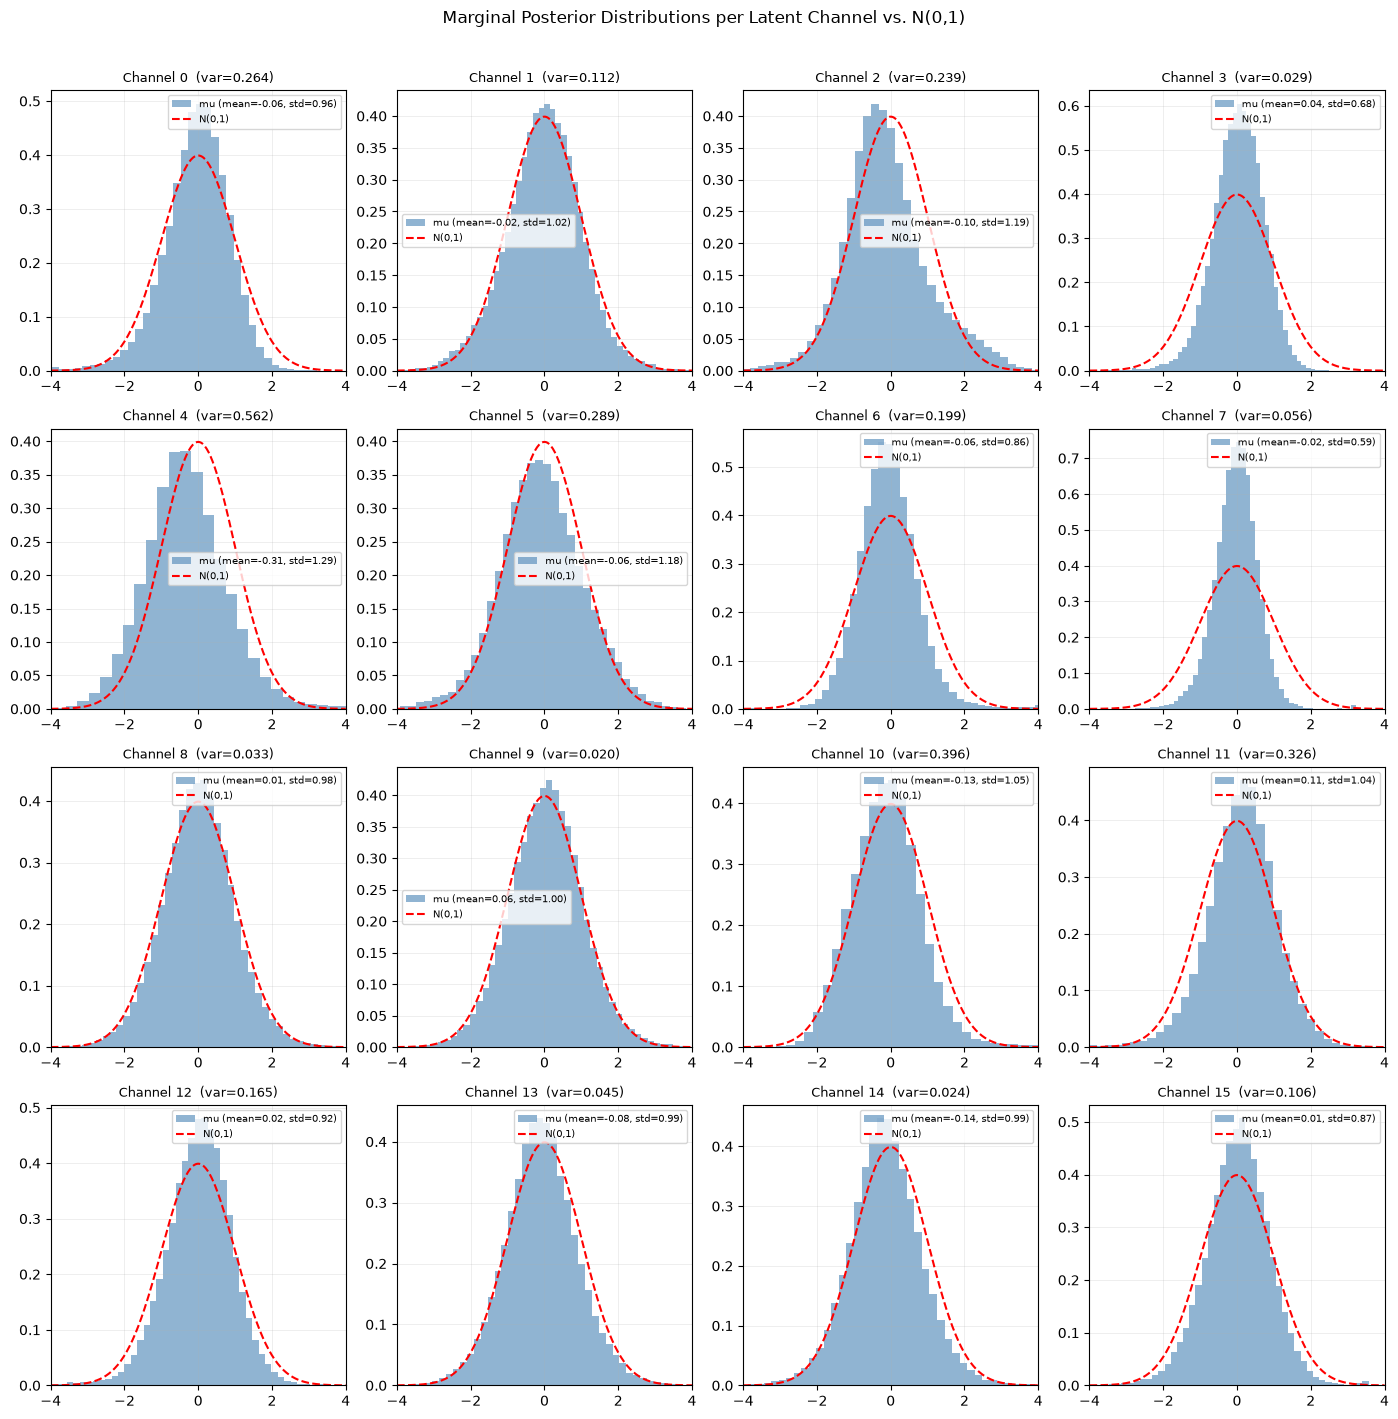

Saved: ../musdb18/output/figures/latent_posterior_histograms.png


In [5]:

n_show = min(16, LATENT_CHANNELS)
cols   = 4
rows   = int(np.ceil(n_show / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
axes = axes.flatten()

x_ref  = np.linspace(-4, 4, 300)
y_ref  = np.exp(-0.5 * x_ref ** 2) / np.sqrt(2 * np.pi)

for c in range(n_show):
    mu_c    = mu_all[:, c, :, :].reshape(-1).numpy()
    sigma_c = sigma_all[:, c, :, :].reshape(-1).numpy()

    axes[c].hist(mu_c, bins=60, density=True, alpha=0.6, color='steelblue',
                 label=f'mu (mean={mu_c.mean():.2f}, std={mu_c.std():.2f})')
    axes[c].plot(x_ref, y_ref, 'r--', linewidth=1.5, label='N(0,1)')
    axes[c].set_title(f'Channel {c}  (var={channel_var[c]:.3f})', fontsize=9)
    axes[c].legend(fontsize=7)
    axes[c].set_xlim(-4, 4)
    axes[c].grid(True, alpha=0.3)

for ax in axes[n_show:]:
    ax.set_visible(False)

plt.suptitle('Marginal Posterior Distributions per Latent Channel vs. N(0,1)',
             fontsize=12, y=1.01)
plt.tight_layout()
out_path = FIGURES_DIR / 'latent_posterior_histograms.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)

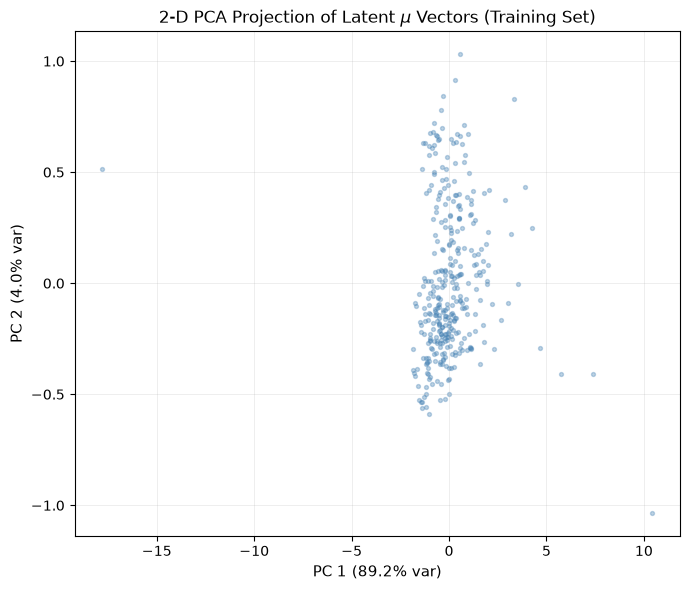

Saved: ../musdb18/output/figures/latent_pca.png
Explained variance: PC1=89.2%, PC2=4.0%


In [6]:
mu_flat_np = mu_flat.numpy()

pca = PCA(n_components=2)
mu_2d = pca.fit_transform(mu_flat_np)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(mu_2d[:, 0], mu_2d[:, 1], alpha=0.35, s=8, c='steelblue')
ax.set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
ax.set_title('2-D PCA Projection of Latent $\\mu$ Vectors (Training Set)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path = FIGURES_DIR / 'latent_pca.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')
print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%')